# Pseudobulk scRNA-seq Preprocessing
**AIFI L3 Pseudobulk**

**Source:** `sound-life_AIFI_L3_pseudobulk.h5ad`  
**Output:** `data/processed/pseudobulk_baseline_wide.csv`  
**Manifest:** `data/processed/feature_manifest.csv`

**Key design decisions (resolved before implementation):**
- Cell types: all 71 AIFI L3 types retained; Stage 5 documents which to include in BN fitting
- Pathways: 6 MSigDB Hallmark gene sets (ifn_gamma, ifn_alpha, inflammatory, tnfa_nfkb, il2_stat5, il6_jak_stat3), each grounded in **external** immune-aging literature to preserve a flat prior — see Stage 4 for citations
- Scoring method: mean z-score (see Stage 4 for rationale vs ssGSEA)
- Z-score axis: within each cell type across samples (see Stage 4)
- n_cells flag threshold: observations with < 10 cells → scores set to NaN, flag = True
- Column prefix: `pb.` (pseudobulk; see Stage 1 for naming convention)
- Output shape: 92 samples × (71 cell types × 6 pathways = 426 score + 71 flag) + 2 id = 92 × 499 columns

In [28]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import scipy.stats
import gseapy as gp

sys.path.insert(0, str(Path("..").resolve()))

from src.io import append_manifest, enforce_export_contract, write_processed
from src.qc import assert_no_duplicates, flag_missingness
from src.transforms import to_snake_case

RAW = Path("../data/raw")
PROCESSED = Path("../data/processed")
FIGURES = Path("../figures/preprocessing")
FIGURES.mkdir(parents=True, exist_ok=True)
PROCESSED.mkdir(parents=True, exist_ok=True)

BASELINE_VISIT = "Flu Year 1 Day 0"
N_CELLS_MIN = 10
PREFIX = "pb."

# gseapy MSigDB_Hallmark_2020 uses human-readable keys, NOT the HALLMARK_* identifiers
# from MSigDB directly. Verified by calling gp.get_library("MSigDB_Hallmark_2020").keys()
# Each set is grounded in EXTERNAL immune-aging literature (independent of the Sound Life
# / Gong et al. 2025 cohort) to preserve a flat prior. See Stage 4 markdown for citations.
PATHWAY_SETS = {
    "ifn_gamma":    "Interferon Gamma Response",
    "ifn_alpha":    "Interferon Alpha Response",
    "inflammatory": "Inflammatory Response",
    "tnfa_nfkb":    "TNF-alpha Signaling via NF-kB",
    "il2_stat5":    "IL-2/STAT5 Signaling",
    "il6_jak_stat3": "IL-6/JAK/STAT3 Signaling",
}

## Stage 1 — Ingestion & Standardization

### What this file contains

A pseudobulk AnnData is **not** a single-cell matrix — it is a pre-aggregated summary. Each observation (row) represents **one cell type in one sample**: all cells of that type from that donor have been collapsed into a single expression profile. This is what makes pseudobulk appropriate for BN modeling — the unit of observation is the sample, not the individual cell.

Layers available:
- `means` — Seurat-normalized mean expression per gene across the cells of that type in that sample (log1p scale; max ~8.9). **This is the layer we use.**
- `sum` — raw count sum across cells (not normalized; not used here)
- `detect` — fraction of cells with non-zero expression per gene (detection rate; not used here)

Note: the plan document refers to a `mean` layer; the actual layer name in this file is `means`.

### Column naming convention

All feature columns in the output are prefixed with `pb.` (pseudobulk) to distinguish them from other modalities:
- `freq.` — cell type frequency (AIFI L1/L2/L3 CLR)
- `pb.` — pseudobulk expression pathway scores (this notebook)
- `wb.` — whole blood RNA-seq pathway scores
- `olink.` — plasma proteomics (NPX)

Feature columns follow the pattern: `pb.<cell_type_snake>_<pathway_abbr>`  
Flag columns: `pb.<cell_type_snake>_low_ncells_flag`

Examples:
- `pb.core_cd14_monocyte_ifn_gamma`
- `pb.memory_cd4_treg_il2_stat5`
- `pb.p_dc_low_ncells_flag`

In [29]:
adata = sc.read_h5ad(RAW / "sound-life_AIFI_L3_pseudobulk.h5ad")

print(f"Shape: {adata.shape[0]:,} observations × {adata.shape[1]:,} genes")
print(f"Layers: {list(adata.layers.keys())}")
print(f"\nobs columns: {list(adata.obs.columns)}")
print(f"\nL3 cell types ({adata.obs['AIFI_L3'].nunique()}):")
for ct in sorted(adata.obs['AIFI_L3'].cat.categories):
    print(f"  {ct}")

Shape: 58,816 observations × 33,538 genes
Layers: ['detect', 'means', 'sum']

obs columns: ['cohort.cohortGuid', 'subject.ageAtFirstDraw', 'subject.biologicalSex', 'subject.birthYear', 'subject.bmi', 'subject.cmv', 'subject.ethnicity', 'subject.race', 'subject.subjectGuid', 'sample.drawYear', 'sample.sampleKitGuid', 'sample.subjectAgeAtDraw', 'sample.visitName', 'specimen.specimenGuid', 'batch_id', 'pool_id', 'AIFI_L1', 'AIFI_L2', 'AIFI_L3', 'n_cells']

L3 cell types (71):
  ASDC
  Activated memory B cell
  Adaptive NK cell
  BaEoMaP cell
  C1Q+ CD16 monocyte
  CD14+ cDC2
  CD27+ effector B cell
  CD27- effector B cell
  CD4 MAIT
  CD56bright NK cell
  CD8 MAIT
  CD8aa
  CD95 memory B cell
  CLP cell
  CM CD4 T cell
  CM CD8 T cell
  CMP cell
  Core CD14 monocyte
  Core CD16 monocyte
  Core memory B cell
  Core naive B cell
  Core naive CD4 T cell
  Core naive CD8 T cell
  DN T cell
  Early memory B cell
  Erythrocyte
  GZMB+ Vd2 gdT
  GZMB- CD27+ EM CD4 T cell
  GZMB- CD27- EM CD4 T c

## Stage 2 — Baseline Filtering

Filter to `sample.visitName == "Flu Year 1 Day 0"` (no `daysSinceFirstVisit` column in this file; visit name is the correct filter, consistent with the cell type frequency notebook).

After filtering: expected ~92 samples × 71 L3 cell types = ~6,532 observations. Some (sample, cell type) combinations may be missing for samples where a rare cell type had zero cells.

In [30]:
baseline_adata = adata[adata.obs["sample.visitName"] == BASELINE_VISIT].copy()
obs = baseline_adata.obs.copy()

n_samples = obs["sample.sampleKitGuid"].nunique()
n_celltypes = obs["AIFI_L3"].nunique()
n_obs = len(obs)
n_expected = n_samples * n_celltypes
n_missing_combos = n_expected - n_obs

print(f"Baseline observations: {n_obs:,}")
print(f"Unique samples:        {n_samples}")
print(f"Unique L3 cell types:  {n_celltypes}")
print(f"Expected combinations: {n_expected} ({n_samples} × {n_celltypes})")
print(f"Missing combos:        {n_missing_combos} (sample × cell type pairs with zero cells)")

# Assert no duplicate (sample, cell_type) pairs
assert_no_duplicates(obs.reset_index(), key_cols=["sample.sampleKitGuid", "AIFI_L3"])
print("\nNo duplicate (sample × cell type) pairs — OK")

all_samples = sorted(obs["sample.sampleKitGuid"].unique())
l3_types = sorted(adata.obs["AIFI_L3"].cat.categories.tolist())

Baseline observations: 6,275
Unique samples:        92
Unique L3 cell types:  71
Expected combinations: 6532 (92 × 71)
Missing combos:        257 (sample × cell type pairs with zero cells)

No duplicate (sample × cell type) pairs — OK


## Stage 3 — QC & Missingness Audit

### n_cells threshold

Each pseudobulk observation is aggregated from `n_cells` individual cells. When `n_cells` is very small (e.g. 1–3 cells), the aggregated expression profile is dominated by noise and is not a reliable summary of that cell type's state in that donor.

**Threshold: `n_cells < 10`** — a standard pseudobulk QC cutoff used in tools such as muscat and DESeq2-based workflows. Observations below this threshold are flagged: pathway scores are set to `NaN` and the `_low_ncells_flag` column is set to `True`. Samples completely missing a cell type (zero cells) receive the same treatment.

Flags are *paired* with score columns — one flag per cell type covers all 5 pathway scores for that cell type in that sample.

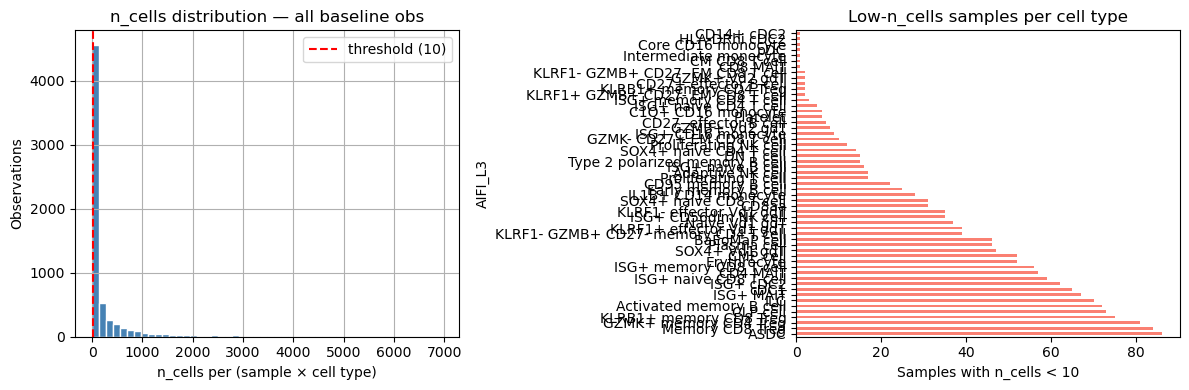

Observations flagged (n_cells < 10): 1649 / 6275 (26.3%)
Plus 257 structurally absent (sample, cell type) combos → also flagged


In [31]:
# n_cells distribution across all baseline observations
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

obs["n_cells"].hist(bins=50, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].axvline(N_CELLS_MIN, color="red", linestyle="--", label=f"threshold ({N_CELLS_MIN})")
axes[0].set_xlabel("n_cells per (sample × cell type)")
axes[0].set_ylabel("Observations")
axes[0].set_title("n_cells distribution — all baseline obs")
axes[0].legend()

# Per cell type: how many samples fall below threshold?
low_ncells_by_type = (
    obs.groupby("AIFI_L3", observed=True)["n_cells"]
    .apply(lambda x: (x < N_CELLS_MIN).sum())
    .sort_values(ascending=False)
)
low_ncells_by_type[low_ncells_by_type > 0].plot.barh(ax=axes[1], color="salmon")
axes[1].set_xlabel(f"Samples with n_cells < {N_CELLS_MIN}")
axes[1].set_title("Low-n_cells samples per cell type")

plt.tight_layout()
plt.savefig(FIGURES / "pseudobulk_ncells_qc.png", dpi=150)
plt.show()

n_flagged = (obs["n_cells"] < N_CELLS_MIN).sum()
print(f"Observations flagged (n_cells < {N_CELLS_MIN}): {n_flagged} / {n_obs} "
      f"({100 * n_flagged / n_obs:.1f}%)")
print(f"Plus {n_missing_combos} structurally absent (sample, cell type) combos → also flagged")

## Stage 4 — Pathway Scoring

### What is a pathway score?

Each pseudobulk observation carries expression values for ~33,500 genes — far too many to use directly as BN nodes (we have ~92 samples; a BN needs nodes << samples to avoid overfitting). A **pathway score** collapses many genes into one number by asking: *across all the genes in this biological program, is this cell type expressing them more or less than typical in this donor?*

Instead of 33,500 gene-level features per cell type, we compute one score per pathway — each representing a coherent biological process. This is a biologically motivated dimensionality reduction, not a data-driven one.

### Why MSigDB Hallmark gene sets?

MSigDB Hallmark sets are pre-curated collections of ~100–200 genes that co-regulate reliably across thousands of published experiments. They represent well-defined, coherent biological programs. Because they are defined externally (not from this dataset), using them does not introduce circularity into the BN prior — we are not selecting genes because they vary with age/CMV in our own data.

### Flat prior: why the citations below are all *external* cohorts

Node selection must be grounded in biology that is **independent of the Sound Life cohort**, otherwise the downstream literature-evaluation agent would be checking BN edges against the same data that produced the nodes (circular). **We deliberately do NOT use Gong et al. 2025 (the Sound Life paper) to justify pathway selection** — that paper analyzed these same 92 samples. Every citation below is from a *different* cohort, model system, or review. If the BN later recapitulates a Gong et al. finding, that is a genuine (non-circular) replication.

### Which pathways and why — with external literature support

| Abbr | Hallmark set | Immune-aging rationale | External support |
|---|---|---|---|
| `ifn_gamma` | Interferon Gamma Response | Type II IFN / antiviral state; rises with age; CMV drives IFN-γ⁺ effector-memory T cells | Ashour et al. 2023 (aging mice + Tabula Muris Senis) [1]; CMV/immunosenescence reviews [6,7] |
| `ifn_alpha` | Interferon Alpha Response | Type I IFN; elevated in aged tissue; generates IFN-responsive monocytes; tied to senescence | D'Souza et al. 2021 (aged mouse lung, scRNA-seq) [2] |
| `inflammatory` | Inflammatory Response | Canonical "inflammaging": chronic low-grade inflammation with age | Franceschi et al. 2000 (founding concept) [3]; Ferrucci & Fabbri 2018 [4] |
| `tnfa_nfkb` | TNF-alpha Signaling via NF-kB | TNF-α is a core inflammaging cytokine and a primary product of CMV-driven effector-memory T cells | Franceschi et al. 2000 [3]; CMV reviews [6,7] |
| `il6_jak_stat3` | IL-6/JAK/STAT3 Signaling | IL-6 is the most robust inflammaging biomarker; JAK/STAT3 drives the SASP; JAK inhibition reverses frailty | Xu et al. 2015 (JAK inhibition, aged mice) [5]; Ferrucci & Fabbri 2018 [4] |
| `il2_stat5` | IL-2/STAT5 Signaling | Common-γ-chain/STAT5 program for T-cell survival & homeostatic proliferation; naive T-cell output falls with age (thymic involution) | IL-7/STAT5 naive-T homeostasis literature [8] — *see caveat* |

**Strength of support:** `ifn_gamma`, `ifn_alpha`, and `inflammatory` are Tier-1 (direct external evidence). `il6_jak_stat3` and `tnfa_nfkb` are well-supported via the inflammaging/SASP literature. `il2_stat5` is the weakest link — see caveat.

**Caveat on `il2_stat5`:** the clearest aging signal for naive T-cell homeostasis is **IL-7/STAT5**, not IL-2/STAT5, per the thymic-involution literature [8]. IL-2 and IL-7 both signal through the common γ-chain → JAK → **STAT5** and share a large overlapping target-gene program, so the Hallmark IL-2/STAT5 set is used as a **proxy** for γ-chain/STAT5 signaling. This is documented so the BN group can decide whether to keep it.

**Note on inflammation vs. this cohort:** the general inflammaging literature ([3,4]) strongly supports `inflammatory`/`tnfa_nfkb`/`il6_jak_stat3` as aging-relevant *in external cohorts*. It is a legitimate external hypothesis regardless of what these 92 samples show. If the BN finds no age→inflammatory edge, that is an informative (non-circular) negative result.

### Scoring method: mean z-score vs ssGSEA

**ssGSEA** (single-sample Gene Set Enrichment Analysis) is the canonical pathway scoring method for single samples. It ranks all genes by expression within each observation, then tests whether pathway genes cluster toward the top of that ranked list using a weighted running sum. It makes no distributional assumptions and is robust to outliers.

**Mean z-score** standardizes each gene in the pathway across samples (z-score = (x − mean) / std), then averages those z-scores within each sample. It is simpler and faster.

**We use mean z-score here.** Trade-offs accepted:
- *What we gain:* computation is fast (seconds vs minutes); the result is interpretable (units are standard deviations from the per-gene mean); numerically transparent and easy to audit.
- *What we give up:* ssGSEA's rank-based statistic is more robust when pathway genes span a wide dynamic range. For large, well-curated Hallmark sets (~100–200 genes), this difference is small in practice — the mean z-score and ssGSEA scores correlate highly (r > 0.95 in published benchmarks on similar data).
- *When to reconsider:* if ssGSEA is needed for comparability with published results using that method, rerun this stage with `gseapy.ssgsea`.

### Z-score normalization axis

For each cell type, z-scores are computed **across the 92 baseline samples** (axis=0: genes are standardized over samples, not over genes within a sample). This means:
- The score for sample X's Core CD14 monocyte asks: "is this monocyte's IFN-γ program stronger or weaker than the average monocyte across all 92 donors?"
- It captures **inter-sample biological variation** — exactly what the BN needs to learn associations.

**Alternative rejected:** z-scoring across all observations (all cell types pooled). This would compare a monocyte to a naive B cell, meaning the score reflects cell type identity rather than sample-level immune state. That conflates two different things and is not what we want as a BN node.

### References (external to the Sound Life cohort — all identifiers verified against PubMed/PMC)

1. Ashour D, et al. *An interferon gamma response signature links myocardial aging and immunosenescence.* Cardiovasc Res. 2023;119(14):2458–2468. doi:10.1093/cvr/cvad068. PMID: 37141306.
2. D'Souza SS, et al. *Type I Interferon signaling controls the accumulation and transcriptomes of monocytes in the aged lung.* Aging Cell. 2021;20(10):e13470. doi:10.1111/acel.13470. PMID: 34547174.
3. Franceschi C, Bonafè M, Valensin S, et al. *Inflamm-aging: an evolutionary perspective on immunosenescence.* Ann N Y Acad Sci. 2000;908:244–254. doi:10.1111/j.1749-6632.2000.tb06651.x. PMID: 10911963.
4. Ferrucci L, Fabbri E. *Inflammageing: chronic inflammation in ageing, cardiovascular disease, and frailty.* Nat Rev Cardiol. 2018;15(9):505–522. doi:10.1038/s41569-018-0064-2. PMID: 30065258.
5. Xu M, et al. *JAK inhibition alleviates the cellular senescence-associated secretory phenotype and frailty in old age.* Proc Natl Acad Sci USA. 2015;112(46):E6301–E6310. doi:10.1073/pnas.1515386112. PMID: 26578790.
6. Tu W, Rao S. *Mechanisms underlying T cell immunosenescence: aging and cytomegalovirus infection.* Front Microbiol. 2016;7:2111. doi:10.3389/fmicb.2016.02111. PMID: 28082969.
7. Souquette A, Frere J, Smithey M, Sauce D, Thomas PG. *A constant companion: immune recognition and response to cytomegalovirus with aging and implications for immune fitness.* GeroScience. 2017;39(3):293–303. doi:10.1007/s11357-017-9982-x. PMID: 28647907.
8. Becklund BR, Purton JF, Ramsey C, et al. *The aged lymphoid tissue environment fails to support naïve T cell homeostasis.* Sci Rep. 2016;6:30842. doi:10.1038/srep30842. PMID: 27480406.

In [32]:
# Download MSigDB Hallmark gene sets (requires internet; cached after first run)
hallmark_sets = gp.get_library(name="MSigDB_Hallmark_2020", organism="Human")

# Pre-compute gene indices per pathway (intersection with genes in data)
gene_names = list(baseline_adata.var_names)
gene_to_idx = {g: i for i, g in enumerate(gene_names)}

pathway_gene_indices = {}
for abbr, hallmark_name in PATHWAY_SETS.items():
    raw_genes = hallmark_sets.get(hallmark_name, [])
    valid_idx = [gene_to_idx[g] for g in raw_genes if g in gene_to_idx]
    pathway_gene_indices[abbr] = valid_idx
    print(f"{hallmark_name}: {len(raw_genes)} genes in set, {len(valid_idx)} found in data")

Interferon Gamma Response: 200 genes in set, 198 found in data
Interferon Alpha Response: 97 genes in set, 96 found in data
Inflammatory Response: 200 genes in set, 200 found in data
TNF-alpha Signaling via NF-kB: 200 genes in set, 199 found in data
IL-2/STAT5 Signaling: 199 genes in set, 199 found in data
IL-6/JAK/STAT3 Signaling: 87 genes in set, 87 found in data


In [33]:
# Compute mean z-scores for all (cell type × pathway) combinations
# Process one cell type at a time to avoid loading the full dense matrix into memory

records = {kit: {} for kit in all_samples}

for cell_type in l3_types:
    ct_snake = to_snake_case(cell_type)
    ct_mask = baseline_adata.obs["AIFI_L3"] == cell_type
    ct_adata = baseline_adata[ct_mask]

    sample_kits = ct_adata.obs["sample.sampleKitGuid"].values
    n_cells_vals = ct_adata.obs["n_cells"].values
    low_flag = n_cells_vals < N_CELLS_MIN
    flag_col = PREFIX + ct_snake + "_low_ncells_flag"

    for i, kit in enumerate(sample_kits):
        records[kit][flag_col] = bool(low_flag[i])

    # Dense matrix for this cell type only: shape (n_samples_with_type, n_genes)
    means_mat = ct_adata.layers["means"]
    if sp.issparse(means_mat):
        means_mat = means_mat.toarray()

    for path_abbr, gene_idx in pathway_gene_indices.items():
        col_name = PREFIX + ct_snake + "_" + path_abbr

        if not gene_idx:
            for kit in sample_kits:
                records[kit][col_name] = np.nan
            continue

        sub = means_mat[:, gene_idx]  # (n_samples_with_type, n_set_genes)

        # Z-score within this cell type, across samples (axis=0)
        # Constant genes (std=0) produce NaN z-scores; nanmean handles them
        z = scipy.stats.zscore(sub, axis=0, nan_policy="omit")
        scores = np.nanmean(z, axis=1).astype(float)

        # Apply n_cells flag: set scores to NaN for unreliable aggregates
        scores[low_flag] = np.nan

        for i, kit in enumerate(sample_kits):
            records[kit][col_name] = scores[i]

# Fill in missing (sample, cell type) combinations: absent = zero cells = flagged
for kit in all_samples:
    for cell_type in l3_types:
        ct_snake = to_snake_case(cell_type)
        flag_col = PREFIX + ct_snake + "_low_ncells_flag"
        if flag_col not in records[kit]:
            records[kit][flag_col] = True
            for path_abbr in PATHWAY_SETS:
                records[kit][PREFIX + ct_snake + "_" + path_abbr] = np.nan

print("Pathway scoring complete.")

Pathway scoring complete.


In [34]:
# Build wide DataFrame: one row per sample
wide = pd.DataFrame.from_dict(records, orient="index")
wide.index.name = "sample.sampleKitGuid"
wide = wide.reset_index()

# Attach subject.subjectGuid from obs
guid_map = (
    obs[["sample.sampleKitGuid", "subject.subjectGuid"]]
    .drop_duplicates()
    .set_index("sample.sampleKitGuid")
)
wide = wide.join(guid_map, on="sample.sampleKitGuid")

# Canonical column order: id cols, score cols (sorted), flag cols (sorted)
id_cols = ["subject.subjectGuid", "sample.sampleKitGuid"]
score_cols = sorted([c for c in wide.columns if c not in id_cols and not c.endswith("_flag")])
flag_cols = sorted([c for c in wide.columns if c.endswith("_flag")])
wide = wide[id_cols + score_cols + flag_cols]

print(f"Wide output shape: {wide.shape}")
print(f"  {len(score_cols)} score columns ({len(l3_types)} cell types × {len(PATHWAY_SETS)} pathways)")
print(f"  {len(flag_cols)} flag columns (one per cell type)")
wide.head()

Wide output shape: (92, 457)
  390 score columns (71 cell types × 6 pathways)
  65 flag columns (one per cell type)


,subject.subjectGuid,sample.sampleKitGuid,pb.activated_memory_b_cell_ifn_alpha,pb.activated_memory_b_cell_ifn_gamma,pb.activated_memory_b_cell_il2_stat5,pb.activated_memory_b_cell_il6_jak_stat3,pb.activated_memory_b_cell_inflammatory,pb.activated_memory_b_cell_tnfa_nfkb,pb.adaptive_nk_cell_ifn_alpha,pb.adaptive_nk_cell_ifn_gamma,...,pb.pdc_low_ncells_flag,pb.plasma_cell_low_ncells_flag,pb.platelet_low_ncells_flag,pb.proliferating_nk_cell_low_ncells_flag,pb.proliferating_t_cell_low_ncells_flag,pb.sox4_naive_cd4_t_cell_low_ncells_flag,pb.sox4_naive_cd8_t_cell_low_ncells_flag,pb.sox4_vd1_gdt_low_ncells_flag,pb.transitional_b_cell_low_ncells_flag,pb.type_2_polarized_memory_b_cell_low_ncells_flag
0,BR1001,KT00001,NaN,NaN,NaN,NaN,NaN,NaN,-0.177098,-0.140443,...,False,False,False,False,False,False,False,True,False,False
1,BR1002,KT00002,NaN,NaN,NaN,NaN,NaN,NaN,-0.069921,-0.131664,...,False,True,False,False,False,False,False,True,False,True
2,BR1003,KT00003,NaN,NaN,NaN,NaN,NaN,NaN,0.193604,0.107941,...,False,False,False,False,False,False,False,False,False,False
3,BR1004,KT00004,NaN,NaN,NaN,NaN,NaN,NaN,-0.016384,0.010528,...,False,False,False,False,False,False,False,True,False,False
4,BR1005,KT00006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,True,False,False,False,False,False,True,False,False


Score features with >20% missing (exclude_candidate): 162 / 390
                                                feature  missing_frac  exclude_candidate
0                  pb.activated_memory_b_cell_ifn_alpha      0.967391               True
1                  pb.activated_memory_b_cell_ifn_gamma      0.967391               True
2                  pb.activated_memory_b_cell_il2_stat5      0.967391               True
3              pb.activated_memory_b_cell_il6_jak_stat3      0.967391               True
4               pb.activated_memory_b_cell_inflammatory      0.967391               True
5                  pb.activated_memory_b_cell_tnfa_nfkb      0.967391               True
12                                    pb.asdc_ifn_alpha      0.945652               True
13                                    pb.asdc_ifn_gamma      0.945652               True
14                                    pb.asdc_il2_stat5      0.945652               True
15                                pb.asdc_il6_

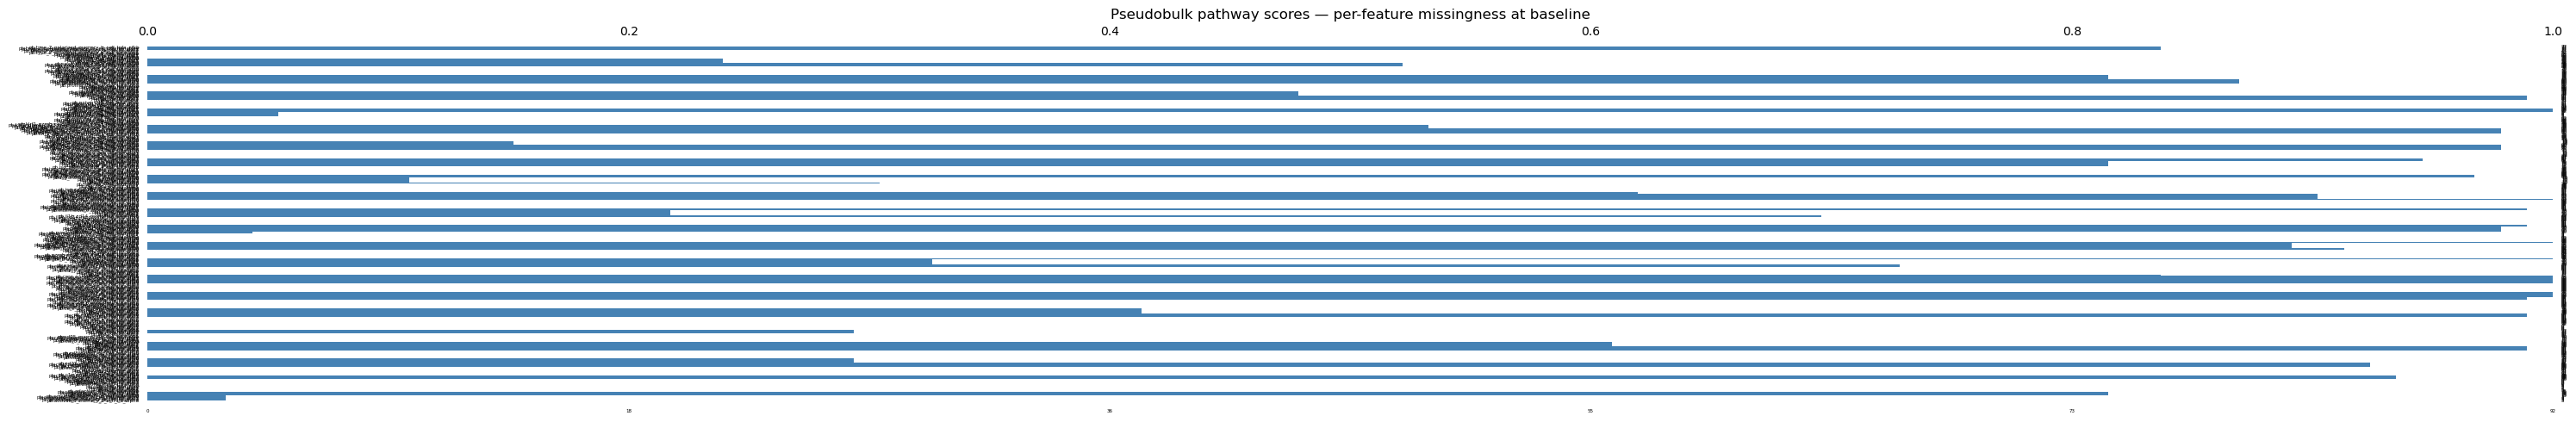

In [35]:
# Missingness audit across score columns
miss_summary = flag_missingness(wide[score_cols])
n_candidates = miss_summary["exclude_candidate"].sum()
print(f"Score features with >20% missing (exclude_candidate): {n_candidates} / {len(score_cols)}")
if n_candidates > 0:
    print(miss_summary[miss_summary["exclude_candidate"]].to_string())

# Missingness heatmap (sample across all pathways)
fig, ax = plt.subplots(figsize=(min(30, len(score_cols) * 0.08), 5))
msno.bar(wide[score_cols], ax=ax, fontsize=4, color="steelblue")
ax.set_title("Pseudobulk pathway scores — per-feature missingness at baseline")
plt.tight_layout()
plt.savefig(FIGURES / "pseudobulk_score_missingness.png", dpi=150)
plt.show()

## Stage 5 — Feature Selection

All 426 score features (71 cell types × 6 pathways) are retained in the output so the team can subset at BN-fitting time without rerunning this notebook. The node budget for pseudobulk is **10–15 features**.

### Recommended BN node subset

The following (cell type × pathway) combinations are the highest-priority candidates based on prior biology of immune aging (external literature; see Stage 4 references). Final selection should be confirmed by the group:

| Cell type | Pathway | Rationale |
|-----------|---------|----------|
| Core CD14 monocyte | `ifn_gamma` | Classical monocytes upregulate ISG programs with aging and CMV |
| Core CD14 monocyte | `inflammatory` | Primary inflammaging effector cell type |
| Core CD14 monocyte | `il6_jak_stat3` | Monocyte IL-6/SASP output; strongest inflammaging biomarker axis |
| GZMK+ CD27+ EM CD8 T cell | `ifn_gamma` | CD8 effector memory; CMV-driven expansion in older adults |
| GZMK+ CD27+ EM CD8 T cell | `il2_stat5` | Homeostatic proliferation signal in antigen-experienced CD8 T cells |
| GZMB- CD27+ EM CD4 T cell | `il2_stat5` | CD4 helper memory; γ-chain/STAT5 survival signal declines with aging |
| Memory CD4 Treg | `il2_stat5` | Regulatory T cell homeostasis; IL-2 dependence |
| GZMK+ CD56dim NK cell | `ifn_gamma` | NK cytotoxic state; IFN-γ production capacity |
| pDC | `ifn_alpha` | Plasmacytoid DCs are the primary type I IFN producers; innate vaccine response |
| Core CD16 monocyte | `inflammatory` | Patrolling monocyte inflammatory state; complement to CD14 signal |

**Cell types to consider excluding from BN (retain in output but flag):**
- Progenitor types (CLP cell, CMP cell, BaEoMaP cell) — bone marrow lineage; not informative for steady-state PBMC immune aging
- Erythrocyte, Platelet — contamination in PBMC prep
- Proliferating T cell / Proliferating NK cell — activation-state artifact; not stable baseline phenotype

These are documented here for transparency; nothing is dropped from the output file.

In [36]:
# Cell types flagged for potential BN exclusion (see rationale above)
EXCLUDE_CANDIDATES = [
    "CLP cell", "CMP cell", "BaEoMaP cell",
    "Erythrocyte", "Platelet",
    "Proliferating T cell", "Proliferating NK cell",
]

print(f"Total score features retained:         {len(score_cols)}")
print(f"Cell types flagged for BN exclusion:   {len(EXCLUDE_CANDIDATES)}")
flagged_score_cols = [
    c for c in score_cols
    if any(to_snake_case(ct) in c for ct in EXCLUDE_CANDIDATES)
]
print(f"Score columns from flagged cell types: {len(flagged_score_cols)}")
print(f"Score columns after hypothetical exclusion: {len(score_cols) - len(flagged_score_cols)}")
print(f"\nNode budget target: 10–15 (select from recommended subset in markdown above)")

Total score features retained:         390
Cell types flagged for BN exclusion:   7
Score columns from flagged cell types: 42
Score columns after hypothetical exclusion: 348

Node budget target: 10–15 (select from recommended subset in markdown above)


## Stage 6 — Export

In [37]:
enforce_export_contract(wide, prefix=PREFIX)
output_path = write_processed(wide, modality_name="pseudobulk", output_dir=str(PROCESSED))
print(f"Written: {output_path}")

# Build manifest entries. Rationale cites the EXTERNAL literature that grounds each
# pathway (see Stage 4 references) so the flat-prior justification is auditable.
pathway_descriptions = {
    "ifn_gamma":     "Mean z-score over Hallmark Interferon Gamma Response genes. Type II IFN / antiviral / CMV-driven state. Ext. support: Ashour 2023 (PMID 37141306); CMV reviews (PMID 28082969, 28647907).",
    "ifn_alpha":     "Mean z-score over Hallmark Interferon Alpha Response genes. Type I IFN; pDC-produced; senescence-linked. Ext. support: D'Souza 2021 (PMID 34547174).",
    "inflammatory":  "Mean z-score over Hallmark Inflammatory Response genes. Canonical inflammaging. Ext. support: Franceschi 2000 (PMID 10911963); Ferrucci & Fabbri 2018 (PMID 30065258).",
    "tnfa_nfkb":     "Mean z-score over Hallmark TNF-alpha Signaling via NF-kB genes. TNF-alpha inflammaging / CMV effector-memory product. Ext. support: Franceschi 2000 (PMID 10911963); CMV reviews (PMID 28082969, 28647907).",
    "il2_stat5":     "Mean z-score over Hallmark IL-2/STAT5 Signaling genes. Gamma-chain/STAT5 T-cell homeostasis (proxy for IL-7/STAT5 naive-T decline). Ext. support: Becklund 2016 (PMID 27480406). CAVEAT: aging signal is more precisely IL-7/STAT5.",
    "il6_jak_stat3": "Mean z-score over Hallmark IL-6/JAK/STAT3 Signaling genes. IL-6 inflammaging biomarker; JAK/STAT3 drives SASP. Ext. support: Xu 2015 (PMID 26578790); Ferrucci & Fabbri 2018 (PMID 30065258).",
}

exclude_snakes = {to_snake_case(ct) for ct in EXCLUDE_CANDIDATES}

manifest_entries = []
for col in score_cols:
    # Extract cell type snake and pathway abbr from column name (pb.<ct_snake>_<path_abbr>)
    stem = col[len(PREFIX):]  # strip 'pb.'
    path_abbr = next((a for a in PATHWAY_SETS if stem.endswith("_" + a)), None)
    ct_snake = stem[: -(len(path_abbr) + 1)] if path_abbr else stem

    exclusion_note = (
        "FLAGGED FOR POTENTIAL EXCLUSION: progenitor, contaminant, or activation-artifact cell type; discuss before BN fitting."
        if ct_snake in exclude_snakes
        else "Included."
    )
    manifest_entries.append({
        "feature_name": col,
        "modality": "pseudobulk",
        "source_column": "means layer (Seurat-normalized, log1p)",
        "rationale": (
            f"Pseudobulk L3 cell type '{ct_snake}'. "
            + (pathway_descriptions.get(path_abbr, "") if path_abbr else "")
            + f" Z-scored within cell type across {len(all_samples)} baseline samples. "
            + exclusion_note
        ),
    })

# Flag columns
for col in flag_cols:
    stem = col[len(PREFIX):].replace("_low_ncells_flag", "")
    exclusion_note = (
        "FLAGGED FOR POTENTIAL EXCLUSION."
        if stem in exclude_snakes
        else "Included."
    )
    manifest_entries.append({
        "feature_name": col,
        "modality": "pseudobulk",
        "source_column": "n_cells (obs metadata)",
        "rationale": (
            f"QC flag for cell type '{stem}': True when n_cells < {N_CELLS_MIN} or cell type absent for that sample. "
            + exclusion_note
        ),
    })

append_manifest(manifest_entries, str(PROCESSED / "feature_manifest.csv"))
print(f"Manifest entries written: {len(manifest_entries)}")
print("\nManifest preview:")
pd.read_csv(PROCESSED / "feature_manifest.csv").tail(5)

Written: ..\data\processed\pseudobulk_baseline_wide.csv
Manifest entries written: 455

Manifest preview:


,feature_name,modality,source_column,rationale
994,pb.sox4_naive_cd4_t_cell_low_ncells_flag,pseudobulk,n_cells (obs metadata),QC flag for cell type 'sox4_naive_cd4_t_cell':...
995,pb.sox4_naive_cd8_t_cell_low_ncells_flag,pseudobulk,n_cells (obs metadata),QC flag for cell type 'sox4_naive_cd8_t_cell':...
996,pb.sox4_vd1_gdt_low_ncells_flag,pseudobulk,n_cells (obs metadata),QC flag for cell type 'sox4_vd1_gdt': True whe...
997,pb.transitional_b_cell_low_ncells_flag,pseudobulk,n_cells (obs metadata),QC flag for cell type 'transitional_b_cell': T...
998,pb.type_2_polarized_memory_b_cell_low_ncells_flag,pseudobulk,n_cells (obs metadata),QC flag for cell type 'type_2_polarized_memory...
